## Load Dataset

In [ ]:
!pip install -U datasets huggingface_hub fsspec

In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import datasets
from tqdm import tqdm
import numpy as np
import pandas as pd
from tokenizers import Tokenizer
import requests

In [2]:
dataset = datasets.load_dataset("wmt/wmt14", "fr-en")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00003.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

train-00001-of-00003.parquet:   0%|          | 0.00/265M [00:00<?, ?B/s]

train-00002-of-00003.parquet:   0%|          | 0.00/273M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/474k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/509k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4508785 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3003 [00:00<?, ? examples/s]

In [127]:
df = pd.DataFrame(dataset["train"]["translation"])

In [128]:
df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["de_len"] = df["de"].apply(lambda x: len(x.split()))

In [129]:
df.drop(df[df["en_len"] > 100].index, inplace=True)
df.drop(df[df["de_len"] > 100].index, inplace=True)

<Axes: ylabel='Frequency'>

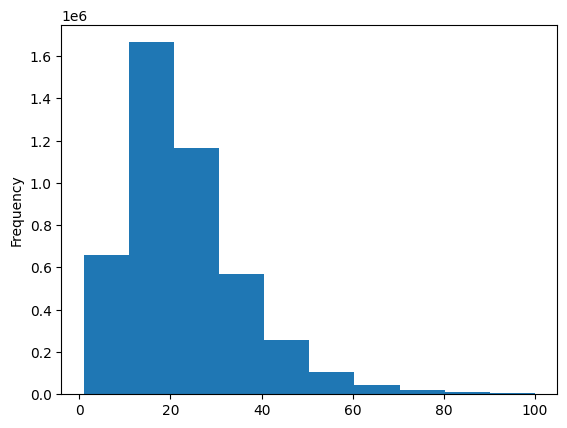

In [6]:
df["en_len"].plot(kind="hist", bins=10)

In [130]:
from sklearn.model_selection import train_test_split
def sample(df, size, val_split):
    num_bins = 10  # increase/decrease depending on precision vs sample size tradeoff
    df['bin'] = pd.cut(df['en_len'], bins=num_bins)
    sampled_df = (
        df.groupby('bin', group_keys=False)
        .apply(lambda x: x.sample(frac=size / len(df), random_state=42))
    )
    train_df, temp_df = train_test_split(
        sampled_df,
        test_size=val_split,  # 20% goes to val+test
        stratify=sampled_df['bin'],
        random_state=42
    )

    # Step 2: Stratified split of temp into val and test
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,  # split remaining 20% equally
        stratify=temp_df['bin'],
        random_state=42
    )
    train_df.drop(columns=['bin'], inplace=True)
    val_df.drop(columns=['bin'], inplace=True)
    test_df.drop(columns=['bin'], inplace=True)
    return train_df, val_df, test_df


In [131]:
train_df, val_df, test_df = sample(df, 150000, 0.2)

/tmp/ipython-input-130-2731617688.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('bin', group_keys=False)
/tmp/ipython-input-130-2731617688.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=size / len(df), random_state=42))


## Preprocess and Build Vocab

In [61]:
import re
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = sentence.replace("&", "and")
    sentence = re.sub(r"[^äöüßa-z0-9\!?.,]", " ", sentence)
    sentence = re.sub(r" +", " ", sentence)
    return sentence

In [63]:
train_df["en"] = train_df["en"].apply(preprocess_sentence)
train_df["de"] = train_df["de"].apply(preprocess_sentence)

In [80]:
import nltk
nltk.download("punkt_tab")
tokenizer = nltk.tokenize.word_tokenize

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [91]:
from collections import Counter
en_vocab_counter = Counter()
de_vocab_counter = Counter()

for sentence in train_df["en"]:
    tokens = tokenizer(sentence)
    en_vocab_counter.update(tokens)

for sentence in train_df["de"]:
    tokens = tokenizer(sentence)
    de_vocab_counter.update(tokens)

In [92]:
max_vocab_size_en = 30000
max_vocab_size_de = 50000
min_freq = 2

pad_idx, unk_idx, sos_idx, eos_idx = 0, 1, 2, 3
en_vocab = {"<pad>": pad_idx, "<unk>": unk_idx, "<sos>": sos_idx, "<eos>": eos_idx}
de_vocab = {"<pad>": pad_idx, "<unk>": unk_idx, "<sos>": sos_idx, "<eos>": eos_idx}

for word, freq in en_vocab_counter.most_common():
    if freq >= min_freq and len(en_vocab) < max_vocab_size_en:
        en_vocab[word] = len(en_vocab)

for word, freq in de_vocab_counter.most_common():
    if freq >= min_freq and len(de_vocab) < max_vocab_size_de:
        de_vocab[word] = len(de_vocab)

In [93]:
import json
with open("en_vocab.json", "w") as f:
    json.dump(en_vocab, f)

with open("de_vocab.json", "w") as f:
    json.dump(de_vocab, f)

## Load Tokenizer

In [ ]:
text = requests.get("https://raw.githubusercontent.com/TheGEN1U5/DLventures/refs/heads/main/nlp/attention/en_vocab.json").text
with open("en_vocab.json", "w") as f:
    f.write(text)
text = requests.get("https://raw.githubusercontent.com/TheGEN1U5/DLventures/refs/heads/main/nlp/attention/de_vocab.json").text
with open("de_vocab.json", "w") as f:
    f.write(text)
en_vocab = json.load(open("en_vocab.json"))
de_vocab = json.load(open("de_vocab.json"))

In [107]:
import re
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = sentence.replace("&", "and")
    sentence = re.sub(r"[^äöüßa-z0-9\!?.,]", " ", sentence)
    sentence = re.sub(r" +", " ", sentence)
    return sentence
def encode(sentence, vocab):
    sentence = preprocess_sentence(sentence)
    tokens = tokenizer(sentence)
    return [sos_idx] + [vocab.get(token, unk_idx) for token in tokens] + [eos_idx]
def decode(tokens, vocab):
    return " ".join([list(vocab.keys())[list(vocab.values()).index(token)] for token in tokens])

In [132]:
def prepare(df):
    df["en_tokens"] = df["en"].apply(lambda x: torch.tensor(encode(x, en_vocab), dtype=torch.long))
    df["de_tokens"] = df["de"].apply(lambda x: torch.tensor(encode(x, de_vocab), dtype=torch.long))
    df["en_len"] = df["en_tokens"].apply(lambda x: torch.tensor(x.shape[0], dtype=torch.long))
    df["de_len"] = df["de_tokens"].apply(lambda x: torch.tensor(x.shape[0], dtype=torch.long))
    return df

In [133]:
train_df = prepare(train_df)
val_df = prepare(val_df)
test_df = prepare(test_df)

In [134]:
val_df

,de,en,en_len,de_len,en_tokens,de_tokens
78679,Aber auch bei einer eindeutigen Definition wir...,"Even if we can agree on a sound definition, th...",tensor(20),tensor(15),"[tensor(2), tensor(121), tensor(51), tensor(18...","[tensor(2), tensor(59), tensor(31), tensor(42)..."
802763,Aber Kommissar Dimas hat Ihnen die tatsächlich...,"The President-in-Office of the Council did, of...",tensor(108),tensor(67),"[tensor(2), tensor(4), tensor(63), tensor(10),...","[tensor(2), tensor(59), tensor(274), tensor(15..."
1718240,"Zusammenhalt kann nur verstanden werden, wenn ...",And cohesion cannot be understood without the ...,tensor(30),tensor(29),"[tensor(2), tensor(8), tensor(1256), tensor(34...","[tensor(2), tensor(3094), tensor(58), tensor(5..."
4228891,Darüber hinaus existieren umfangreiche Sammlun...,The archive also has major collections of sami...,tensor(36),tensor(33),"[tensor(2), tensor(4), tensor(4300), tensor(41...","[tensor(2), tensor(188), tensor(341), tensor(3..."
4190609,(2) Das Einstellen und die Pflege der Bieterda...,(2) Bidder data is placed and maintained in th...,tensor(28),tensor(24),"[tensor(2), tensor(221), tensor(20248), tensor...","[tensor(2), tensor(172), tensor(13), tensor(49..."
...,...,...,...,...,...,...
1788121,"Wurde bei dieser Konzentration, bei der Aktion...","Similarly, in relation to the employment creat...",tensor(35),tensor(37),"[tensor(2), tensor(3764), tensor(5), tensor(10...","[tensor(2), tensor(66), tensor(42), tensor(56)..."
77060,Die internationale Gemeinschaft hat zugleich d...,The international community also has a duty to...,tensor(34),tensor(32),"[tensor(2), tensor(4), tensor(141), tensor(225...","[tensor(2), tensor(6), tensor(509), tensor(440..."
1650240,Ebenso möchte ich unserem Kollegen Tillich für...,I would also like to offer my sincere thanks t...,tensor(55),tensor(34),"[tensor(2), tensor(23), tensor(47), tensor(41)...","[tensor(2), tensor(416), tensor(86), tensor(25..."
1608289,"Was die Zukunft angeht, meine ich, daß das Gru...","As far as the future is concerned, I believe t...",tensor(48),tensor(41),"[tensor(2), tensor(22), tensor(251), tensor(22...","[tensor(2), tensor(69), tensor(6), tensor(314)..."
